In [1]:
from chapter4.two_layer_net import TwoLayerNet


def f(x):
    return 1/20 * x[0]**2 + x[1]**2

In [2]:
import sys, os
sys.path.append(os.pardir)
from common.gradient import numerical_gradient

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
x = np.linspace(-10, 10, 100)
y = np.linspace(-5, 5, 50)

X, Y = np.meshgrid(x, y)

In [5]:
U, V = np.zeros_like(X), np.zeros_like(Y)
for i in range(U.shape[0]):
    for j in range(U.shape[1]):
        grads = numerical_gradient(f, np.array([X[i, j], Y[i, j]]))
        U[i, j] = -grads[0]
        V[i, j] = -grads[1]


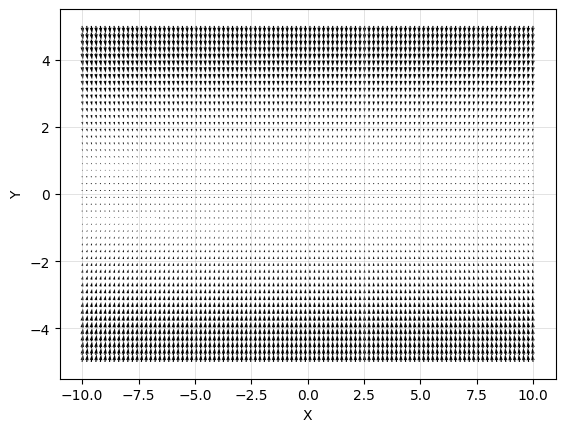

In [6]:
plt.quiver(X, Y, U, V)
plt.xlabel('X')
plt.ylabel('Y')
plt.figaspect(1.0)
plt.grid(True)
plt.show()

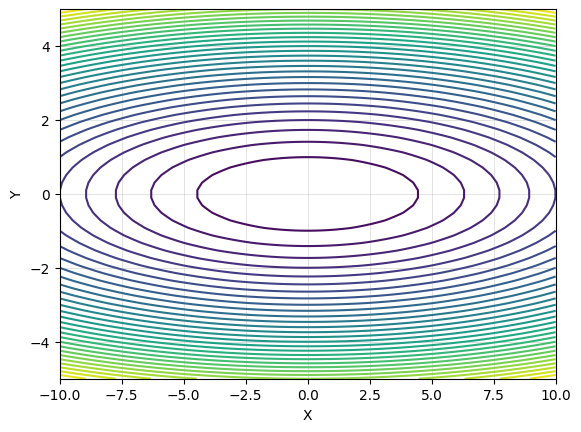

In [10]:
Z = 1 / 20 * X**2 + Y**2
plt.contour(X, Y, Z, levels=30)
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()

In [12]:
init = [-7.0, 2.0]
point_list = []
point_list.append(init)
for i in range(30):
    grads = numerical_gradient(f, np.array(point_list[-1]))
    point_list.append(point_list[-1] - 0.95 * grads)

최종 위치: [-0.350393    0.08478232]
최종 함수값: 0.013326803773157179


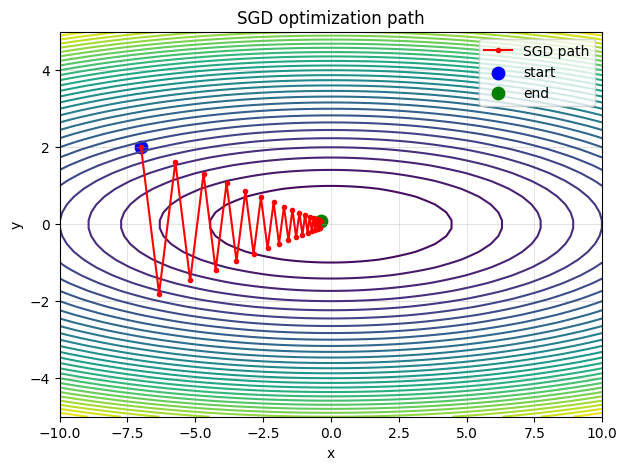

In [13]:
point_list = np.array(point_list)

print("최종 위치:", point_list[-1])
print("최종 함수값:", f(point_list[-1]))

Z = 1 / 20 * X**2 + Y**2

plt.figure(figsize=(7, 5))
plt.contour(X, Y, Z, levels=30)

plt.plot(point_list[:, 0], point_list[:, 1], "o-", color="red", markersize=3, label="SGD path")
plt.scatter(init[0], init[1], color="blue", s=80, label="start")
plt.scatter(point_list[-1, 0], point_list[-1, 1], color="green", s=80, label="end")

plt.xlabel("x")
plt.ylabel("y")
plt.title("SGD optimization path")
plt.legend()
plt.grid(True)
plt.show()